GAN

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# 1. Load MNIST dataset
# ==============================

(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

# Normalize images from [0, 255] to [-1, 1]
x_train = x_train.astype("float32")
x_train = (x_train - 127.5) / 127.5

# Add channel dimension
x_train = np.expand_dims(x_train, axis=-1)

print("Training data shape:", x_train.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Training data shape: (60000, 28, 28, 1)


In [2]:
# ==============================
# 2. Create batches
# ==============================

BUFFER_SIZE = 60000
BATCH_SIZE = 128

dataset = tf.data.Dataset.from_tensor_slices(x_train)
dataset = dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

Generator and Discriminator

In [3]:
# ==============================
# 3. Generator
# ==============================

def create_generator():

    model = tf.keras.Sequential([
        tf.keras.layers.Dense(
            7 * 7 * 256,
            use_bias=False,
            input_shape=(100,)
        ),

        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.LeakyReLU(),

        tf.keras.layers.Reshape((7, 7, 256)),

        tf.keras.layers.Conv2DTranspose(
            128,
            kernel_size=5,
            strides=1,
            padding="same",
            use_bias=False
        ),

        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.LeakyReLU(),

        tf.keras.layers.Conv2DTranspose(
            64,
            kernel_size=5,
            strides=2,
            padding="same",
            use_bias=False
        ),

        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.LeakyReLU(),

        tf.keras.layers.Conv2DTranspose(
            1,
            kernel_size=5,
            strides=2,
            padding="same",
            use_bias=False,
            activation="tanh"
        )
    ])

    return model


# ==============================
# 4. Discriminator
# ==============================

def create_discriminator():

    model = tf.keras.Sequential([

        tf.keras.layers.Conv2D(
            64,
            kernel_size=5,
            strides=2,
            padding="same",
            input_shape=[28, 28, 1]
        ),

        tf.keras.layers.LeakyReLU(),
        tf.keras.layers.Dropout(0.3),

        tf.keras.layers.Conv2D(
            128,
            kernel_size=5,
            strides=2,
            padding="same"
        ),

        tf.keras.layers.LeakyReLU(),
        tf.keras.layers.Dropout(0.3),

        tf.keras.layers.Flatten(),

        tf.keras.layers.Dense(1)
    ])

    return model


generator = create_generator()
discriminator = create_discriminator()


c:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\keras\src\layers\core\dense.py:102: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Loss funcions

In [4]:
# ==============================
# 5. Loss functions
# ==============================

cross_entropy = tf.keras.losses.BinaryCrossentropy(
    from_logits=True
)


def generator_loss(fake_output):

    return cross_entropy(
        tf.ones_like(fake_output),
        fake_output
    )


def discriminator_loss(real_output, fake_output):

    real_loss = cross_entropy(
        tf.ones_like(real_output),
        real_output
    )

    fake_loss = cross_entropy(
        tf.zeros_like(fake_output),
        fake_output
    )

    return real_loss + fake_loss

In [5]:
# ==============================
# 6. Optimizers
# ==============================

generator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0002,
    beta_1=0.5
)

discriminator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0002,
    beta_1=0.5
)

In [6]:
# ==============================
# 7. Training function
# ==============================

@tf.function
def train_step(images):

    noise = tf.random.normal(
        [BATCH_SIZE, 100]
    )

    with tf.GradientTape() as gen_tape, \
         tf.GradientTape() as disc_tape:

        generated_images = generator(
            noise,
            training=True
        )

        real_output = discriminator(
            images,
            training=True
        )

        fake_output = discriminator(
            generated_images,
            training=True
        )

        gen_loss = generator_loss(fake_output)

        disc_loss = discriminator_loss(
            real_output,
            fake_output
        )

    gradients_of_generator = gen_tape.gradient(
        gen_loss,
        generator.trainable_variables
    )

    gradients_of_discriminator = disc_tape.gradient(
        disc_loss,
        discriminator.trainable_variables
    )

    generator_optimizer.apply_gradients(
        zip(
            gradients_of_generator,
            generator.trainable_variables
        )
    )

    discriminator_optimizer.apply_gradients(
        zip(
            gradients_of_discriminator,
            discriminator.trainable_variables
        )
    )

    return gen_loss, disc_loss



Train GAN

In [7]:
# ==============================
# 8. Train GAN
# ==============================

EPOCHS = 10

generator_losses = []
discriminator_losses = []

for epoch in range(EPOCHS):

    gen_epoch_loss = []
    disc_epoch_loss = []

    for image_batch in dataset:

        gen_loss, disc_loss = train_step(image_batch)

        gen_epoch_loss.append(float(gen_loss))
        disc_epoch_loss.append(float(disc_loss))

    avg_gen_loss = np.mean(gen_epoch_loss)
    avg_disc_loss = np.mean(disc_epoch_loss)

    generator_losses.append(avg_gen_loss)
    discriminator_losses.append(avg_disc_loss)

    print(
        f"Epoch {epoch + 1}/{EPOCHS} "
        f"- Generator Loss: {avg_gen_loss:.4f} "
        f"- Discriminator Loss: {avg_disc_loss:.4f}"
    )



Epoch 1/10 - Generator Loss: 0.7036 - Discriminator Loss: 1.3184
Epoch 2/10 - Generator Loss: 0.7689 - Discriminator Loss: 1.3201
Epoch 3/10 - Generator Loss: 0.8330 - Discriminator Loss: 1.2668
Epoch 4/10 - Generator Loss: 0.8651 - Discriminator Loss: 1.2501
Epoch 5/10 - Generator Loss: 0.8067 - Discriminator Loss: 1.3045
Epoch 6/10 - Generator Loss: 0.7953 - Discriminator Loss: 1.3138
Epoch 7/10 - Generator Loss: 0.7945 - Discriminator Loss: 1.3130
Epoch 8/10 - Generator Loss: 0.8040 - Discriminator Loss: 1.3054
Epoch 9/10 - Generator Loss: 0.7986 - Discriminator Loss: 1.3070
Epoch 10/10 - Generator Loss: 0.8048 - Discriminator Loss: 1.3011


PLOT 16 images

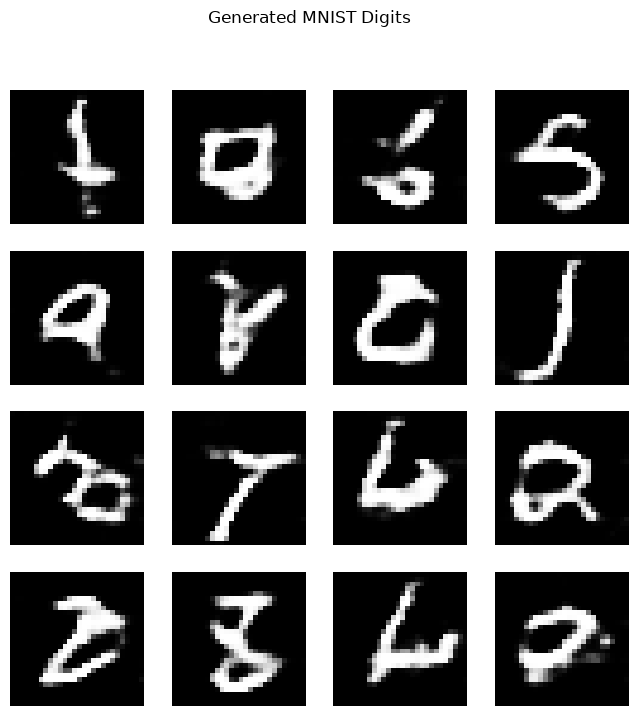

In [8]:
# ==============================
# 9. Generate 16 images
# ==============================

noise = tf.random.normal([16, 100])

generated_images = generator(
    noise,
    training=False
)

generated_images = (generated_images + 1) / 2


plt.figure(figsize=(8, 8))

for i in range(16):

    plt.subplot(4, 4, i + 1)

    plt.imshow(
        generated_images[i, :, :, 0],
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle("Generated MNIST Digits")
plt.show()


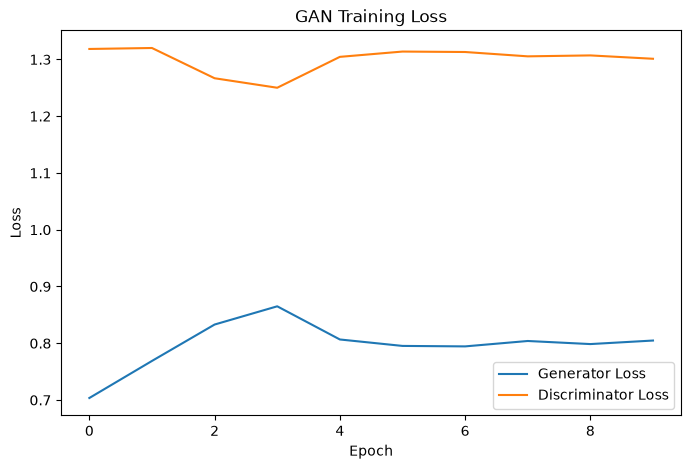

In [9]:
# ==============================
# 10. Plot losses
# ==============================

plt.figure(figsize=(8, 5))

plt.plot(
    generator_losses,
    label="Generator Loss"
)

plt.plot(
    discriminator_losses,
    label="Discriminator Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN Training Loss")
plt.legend()
plt.show()